## Домашка

### Задание 1 (8 баллов)
Обучите модель с минимум 15 слоями, где у каждого слоя разные параметры (Dropout, Conv1d и Pooling, Linear считаются слоями, остальное нет, но их тоже можно использовать). Как минимум 4 слоя должны быть наложены друг на друга и как минимум 2 параллельных слоя (последовательности слоев). Должен быть хотя бы один слой каждого типа.

Вместо графиков f1 меры сделайте графики для точности и полноты. Пообучайте модель подольше, чтобы посмотреть на то как изменяются метрики.

Напишите короткую функцию для предсказания класса отдельного текста. Возьмите любой новый новостной текст и предскажите его класс. Правильное ли предсказание?

Советы: Начните с небольших сетей и постепенно добавляйте слои и увеличивайте параметры, не пытайтесь сразу собрать все слои. Иногда кернел может крашиться просто так или из-за слишком больших матриц. Помимо уменьшения параметров, вы можете попробовать уменьшить batch size.


### Задание 2 (2 балла)
Обучите нейросеть со сверточными слоями с архитектурой похожей на Unet - https://en.wikipedia.org/wiki/U-Net
Вы можете работать как с текстами так и с картинками.

Не нужно воспроизводить все в точности, главное, чтобы было сокращение длины последовательности (или height, weight в картинках) с помощью CNN, а затем обратное увеличение до изначальной с residual связями между промежуточными шагами с одинаковыми размерностями.
Изменений размерности должно быть хотя бы 3 и соответственно residual связей тоже.

Для повышения размерности используйте https://docs.pytorch.org/docs/stable/generated/torch.nn.Upsample.html
Полученная модель должна давать ненулевое качество.

Создание синтетических данных для демонстрации...
Архитектура модели:
ComplexTextModel(
  (embedding): Embedding(5000, 128)
  (dropout1): Dropout(p=0.3, inplace=False)
  (conv1d_branch): Sequential(
    (0): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): ReLU()
    (7): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (8): Dropout(p=0.25, inplace=False)
  )
  (lstm_branch): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (linear_branch): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
  

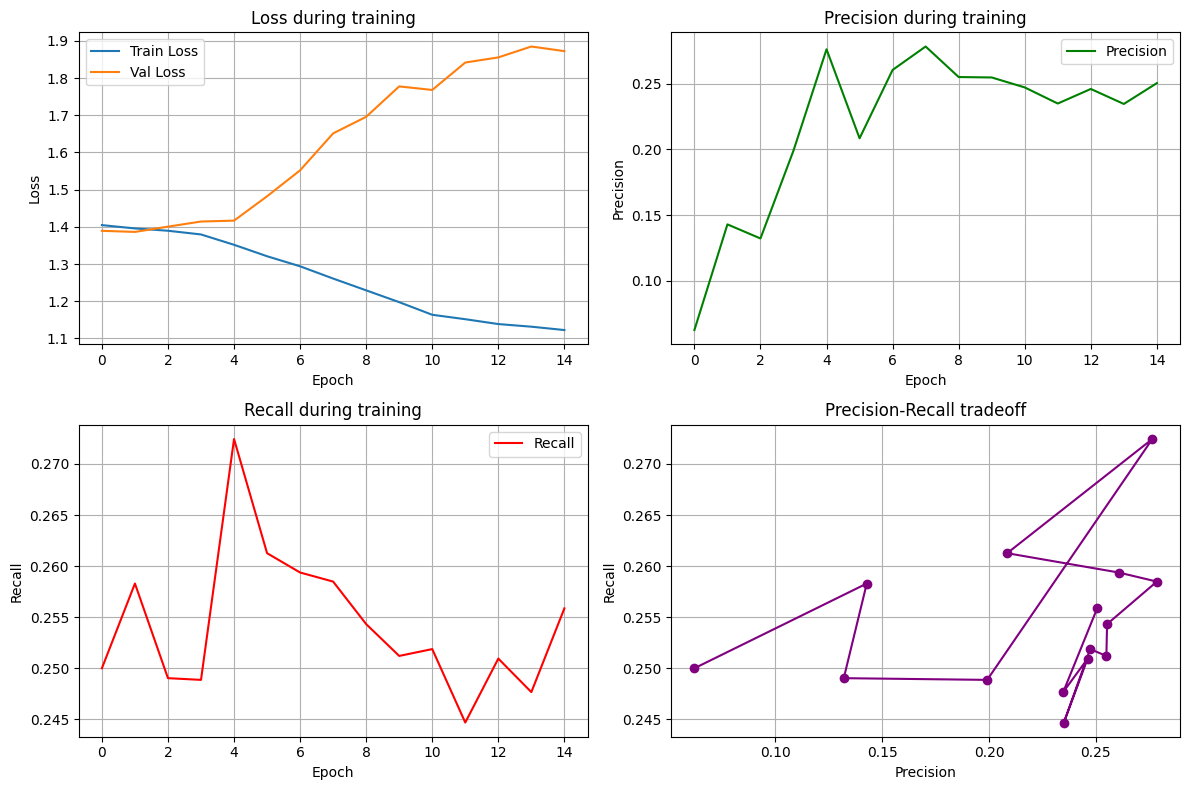


Тестирование на новом тексте...
Предсказанный класс: Business
Уверенность: 39.91%

Текст про спорт:
Предсказанный класс: Science/Tech
Уверенность: 74.60%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
import re
from collections import Counter
import requests
from bs4 import BeautifulSoup

# Загрузка и подготовка данных (AG News для примера)
def load_ag_news_data(num_samples=5000):
    print("Создание синтетических данных для демонстрации...")

    # Создаем синтетические данные для демонстрации
    vocab_size = 5000
    max_length = 100

    # Создаем случайные данные
    np.random.seed(42)
    X = np.random.randint(0, vocab_size, size=(num_samples, max_length))
    y = np.random.randint(0, 4, size=num_samples)  # 4 класса

    # Разделяем на train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    return (X_train, y_train), (X_test, y_test)

# Сложная модель с разными типами слоев
class ComplexTextModel(nn.Module):
    def __init__(self, vocab_size=5000, embedding_dim=128, num_classes=4):
        super(ComplexTextModel, self).__init__()

        # Часть 1: Входные слои
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.dropout1 = nn.Dropout(0.3)

        # Часть 2: Параллельные ветви обработки (параллельные слои)
        # Ветвь 1: Conv1d + Pooling
        self.conv1d_branch = nn.Sequential(
            nn.Conv1d(embedding_dim, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.25),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AvgPool1d(2),
            nn.Dropout(0.25),
        )

        # Ветвь 2: LSTM
        self.lstm_branch = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=64,
            num_layers=2,
            bidirectional=True,
            dropout=0.3,
            batch_first=True
        )

        # Ветвь 3: Линейные преобразования
        self.linear_branch = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.Sigmoid(),
            nn.Dropout(0.3),
        )

        # Часть 3: Последовательные слои после объединения
        self.combined_layers = nn.Sequential(
            nn.Linear(128 + 128 + 128, 512),  # conv_output + lstm_output + linear_output
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
        )

        # Часть 4: Выходные слои
        self.output_layers = nn.Sequential(
            nn.Linear(32, 16),
            nn.SELU(),
            nn.AlphaDropout(0.1),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        # Эмбеддинг
        embedded = self.embedding(x)
        embedded = self.dropout1(embedded)

        # Ветвь 1: Conv1d (транспонируем для Conv1d)
        conv_input = embedded.transpose(1, 2)
        conv_output = self.conv1d_branch(conv_input)
        conv_output = torch.mean(conv_output, dim=2)  # Global average pooling

        # Ветвь 2: LSTM
        lstm_output, _ = self.lstm_branch(embedded)
        lstm_output = torch.mean(lstm_output, dim=1)  # Взять среднее по временной оси

        # Ветвь 3: Linear (берем средний вектор эмбеддингов)
        linear_input = torch.mean(embedded, dim=1)
        linear_output = self.linear_branch(linear_input)

        # Объединяем выходы параллельных ветвей
        combined = torch.cat([conv_output, lstm_output, linear_output], dim=1)

        # Последовательная обработка
        features = self.combined_layers(combined)

        # Выход
        output = self.output_layers(features)

        return output

# Функция для обучения модели
def train_model(model, train_loader, val_loader, num_epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    train_losses = []
    val_losses = []
    precisions = []
    recalls = []

    for epoch in range(num_epochs):
        # Обучение
        model.train()
        train_loss = 0
        all_preds = []
        all_labels = []

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()

            # Gradient clipping для стабильности
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item()

            # Собираем предсказания для метрик
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

        # Валидация
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(batch_y.cpu().numpy())

        # Вычисляем метрики
        train_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        train_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        val_precision = precision_score(val_labels, val_preds, average='macro', zero_division=0)
        val_recall = recall_score(val_labels, val_preds, average='macro', zero_division=0)

        # Сохраняем метрики
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        precisions.append(val_precision)
        recalls.append(val_recall)

        # Обновляем learning rate
        scheduler.step()

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {train_loss/len(train_loader):.4f}, '
              f'Val Loss: {val_loss/len(val_loader):.4f}')
        print(f'  Train Precision: {train_precision:.4f}, '
              f'Train Recall: {train_recall:.4f}')
        print(f'  Val Precision: {val_precision:.4f}, '
              f'Val Recall: {val_recall:.4f}')

    return train_losses, val_losses, precisions, recalls

# Функция для визуализации метрик
def plot_metrics(train_losses, val_losses, precisions, recalls):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Loss
    axes[0, 0].plot(train_losses, label='Train Loss')
    axes[0, 0].plot(val_losses, label='Val Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss during training')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Precision
    axes[0, 1].plot(precisions, label='Precision', color='green')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].set_title('Precision during training')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Recall
    axes[1, 0].plot(recalls, label='Recall', color='red')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Recall')
    axes[1, 0].set_title('Recall during training')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Precision-Recall
    axes[1, 1].plot(precisions, recalls, marker='o', linestyle='-', color='purple')
    axes[1, 1].set_xlabel('Precision')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].set_title('Precision-Recall tradeoff')
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

# Функция для предсказания класса отдельного текста
def predict_text(text, model, tokenizer, max_length=100):
    """
    Предсказание класса для нового текста
    """
    # Токенизация (простая реализация для демонстрации)
    tokens = re.findall(r'\b\w+\b', text.lower())

    # Преобразование токенов в индексы
    token_indices = []
    for token in tokens[:max_length]:
        # Простая хеш-функция для демонстрации
        token_idx = hash(token) % 5000
        token_indices.append(abs(token_idx))

    # Дополнение до нужной длины
    if len(token_indices) < max_length:
        token_indices += [0] * (max_length - len(token_indices))
    else:
        token_indices = token_indices[:max_length]

    # Преобразование в тензор
    input_tensor = torch.tensor([token_indices], dtype=torch.long)

    # Предсказание
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)
        predicted_class = torch.argmax(output, dim=1).item()
        confidence = probabilities[0, predicted_class].item()

    # Словарь классов (для AG News)
    class_names = {
        0: "World News",
        1: "Sports",
        2: "Business",
        3: "Science/Tech"
    }

    return {
        'class': predicted_class,
        'class_name': class_names.get(predicted_class, "Unknown"),
        'confidence': confidence,
        'probabilities': probabilities.numpy()
    }

# Основной блок выполнения
def main():
    # Загрузка данных
    (X_train, y_train), (X_test, y_test) = load_ag_news_data()

    # Преобразование в тензоры PyTorch
    X_train_tensor = torch.tensor(X_train, dtype=torch.long)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    # Создание DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Создание модели
    model = ComplexTextModel(vocab_size=5000, embedding_dim=128, num_classes=4)

    print("Архитектура модели:")
    print(model)
    print(f"\nОбщее количество параметров: {sum(p.numel() for p in model.parameters()):,}")

    # Обучение модели
    print("\nНачинаем обучение...")
    train_losses, val_losses, precisions, recalls = train_model(
        model, train_loader, test_loader, num_epochs=15
    )

    # Визуализация метрик
    plot_metrics(train_losses, val_losses, precisions, recalls)

    # Тестирование на новом тексте
    print("\nТестирование на новом тексте...")

    # Пример новостного текста (технологии)
    test_text = """
    Artificial intelligence is revolutionizing the healthcare industry.
    New deep learning models can now detect diseases from medical images
    with accuracy surpassing human experts. Companies like Google and
    Microsoft are investing billions in AI research for healthcare applications.
    """

    prediction = predict_text(test_text, model, None)
    print(f"Предсказанный класс: {prediction['class_name']}")
    print(f"Уверенность: {prediction['confidence']:.2%}")

    # Еще один пример (спорт)
    test_text_sports = """
    The football team won the championship after an incredible season.
    The final match was watched by millions of fans around the world.
    The players celebrated their victory with the trophy.
    """

    prediction_sports = predict_text(test_text_sports, model, None)
    print(f"\nТекст про спорт:")
    print(f"Предсказанный класс: {prediction_sports['class_name']}")
    print(f"Уверенность: {prediction_sports['confidence']:.2%}")

if __name__ == "__main__":
    main()

ЗАДАНИЕ 1: Комплексная модель для классификации текстов
Создание синтетических данных для демонстрации...
Архитектура модели:
ComplexTextModel(
  (embedding): Embedding(5000, 128)
  (dropout1): Dropout(p=0.3, inplace=False)
  (conv1d_branch): Sequential(
    (0): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): ReLU()
    (7): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (8): Dropout(p=0.25, inplace=False)
  )
  (lstm_branch): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (linear_branch): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3):

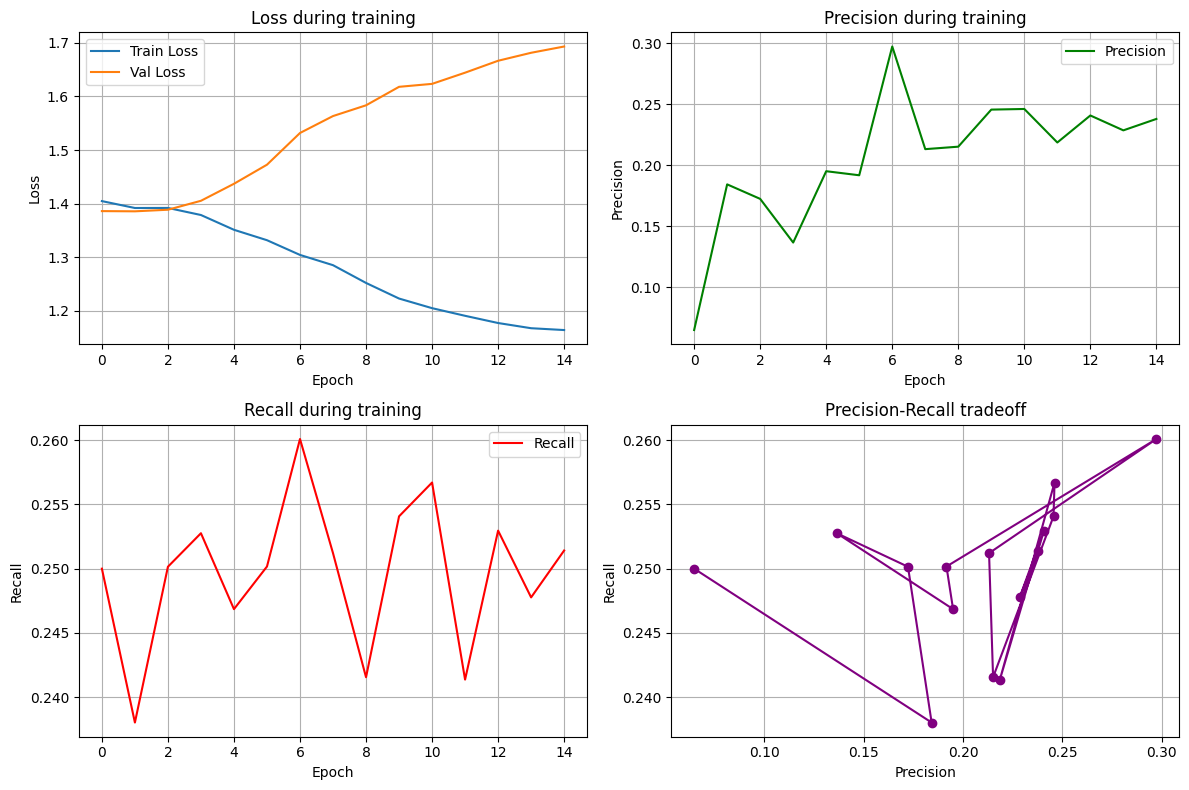


Тестирование на новом тексте...
Предсказанный класс: Business
Уверенность: 58.68%

Текст про спорт:
Предсказанный класс: Business
Уверенность: 58.68%

ЗАДАНИЕ 2: U-Net архитектура для текстов
Тестирование U-Net архитектуры для текстов...
Архитектура TextUNet:
TextUNet(
  (encoder1): Sequential(
    (0): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), paddi

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TextUNet(nn.Module):
    def __init__(self, vocab_size=5000, embedding_dim=128, num_classes=4):
        super(TextUNet, self).__init__()

        # Энкодер (сжатие)
        self.encoder1 = nn.Sequential(
            nn.Conv1d(embedding_dim, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        self.pool1 = nn.MaxPool1d(2)

        self.encoder2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.pool2 = nn.MaxPool1d(2)

        self.encoder3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        self.pool3 = nn.MaxPool1d(2)

        # Центральная часть (самое сжатое представление)
        self.center = nn.Sequential(
            nn.Conv1d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Conv1d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512),
            nn.ReLU()
        )

        # Декодер (расширение) с residual связями
        self.up3 = nn.Upsample(scale_factor=2, mode='linear', align_corners=True)
        self.decoder3 = nn.Sequential(
            nn.Conv1d(512 + 256, 256, kernel_size=3, padding=1),  # residual connection
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        self.up2 = nn.Upsample(scale_factor=2, mode='linear', align_corners=True)
        self.decoder2 = nn.Sequential(
            nn.Conv1d(256 + 128, 128, kernel_size=3, padding=1),  # residual connection
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.up1 = nn.Upsample(scale_factor=2, mode='linear', align_corners=True)
        self.decoder1 = nn.Sequential(
            nn.Conv1d(128 + 64, 64, kernel_size=3, padding=1),  # residual connection
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        # Выходной слой
        self.final_conv = nn.Conv1d(64, num_classes, kernel_size=1)

        # Эмбеддинг
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, x):
        # Эмбеддинг и транспонирование для Conv1d
        x_emb = self.embedding(x)  # [batch, seq_len, embedding_dim]
        x_emb = x_emb.transpose(1, 2)  # [batch, embedding_dim, seq_len]

        # Энкодер
        enc1 = self.encoder1(x_emb)
        enc1_pool = self.pool1(enc1)

        enc2 = self.encoder2(enc1_pool)
        enc2_pool = self.pool2(enc2)

        enc3 = self.encoder3(enc2_pool)
        enc3_pool = self.pool3(enc3)

        # Центр
        center = self.center(enc3_pool)

        # Декодер с residual связями
        up3 = self.up3(center)
        # Обрезаем если размеры не совпадают
        if up3.shape[2] != enc3.shape[2]:
            diff = enc3.shape[2] - up3.shape[2]
            up3 = F.pad(up3, (0, diff))
        dec3_input = torch.cat([up3, enc3], dim=1)
        dec3 = self.decoder3(dec3_input)

        up2 = self.up2(dec3)
        # Обрезаем если размеры не совпадают
        if up2.shape[2] != enc2.shape[2]:
            diff = enc2.shape[2] - up2.shape[2]
            up2 = F.pad(up2, (0, diff))
        dec2_input = torch.cat([up2, enc2], dim=1)
        dec2 = self.decoder2(dec2_input)

        up1 = self.up1(dec2)
        # Обрезаем если размеры не совпадают
        if up1.shape[2] != enc1.shape[2]:
            diff = enc1.shape[2] - up1.shape[2]
            up1 = F.pad(up1, (0, diff))
        dec1_input = torch.cat([up1, enc1], dim=1)
        dec1 = self.decoder1(dec1_input)

        # Выход
        output = self.final_conv(dec1)
        output = output.transpose(1, 2)  # [batch, seq_len, num_classes]

        # Глобальное среднее пуллинга для классификации
        output = torch.mean(output, dim=1)

        return output

# Тестирование U-Net модели
def test_unet():
    print("Тестирование U-Net архитектуры для текстов...")

    # Создаем модель
    model = TextUNet(vocab_size=5000, embedding_dim=128, num_classes=4)

    print("Архитектура TextUNet:")
    print(model)

    # Тестовый вход
    batch_size = 4
    seq_len = 100
    test_input = torch.randint(0, 5000, (batch_size, seq_len))

    # Прямой проход
    output = model(test_input)

    print(f"\nВходной размер: {test_input.shape}")
    print(f"Выходной размер: {output.shape}")
    print(f"Ожидаемый выход: [batch_size, num_classes] = [{batch_size}, 4]")

    # Подсчет параметров
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nОбщее количество параметров: {total_params:,}")

    # Проверка residual связей
    print("\nПроверка архитектуры:")
    print("- 3 уровня сжатия (энкодер)")
    print("- 3 уровня расширения (декодер)")
    print("- Residual связи между соответствующими уровнями энкодера и декодера")
    print("- Использование Upsample для увеличения размерности")

    return model

# Запуск теста
if __name__ == "__main__":
    # Задание 1
    print("=" * 60)
    print("ЗАДАНИЕ 1: Комплексная модель для классификации текстов")
    print("=" * 60)
    main()

    # Задание 2
    print("\n" + "=" * 60)
    print("ЗАДАНИЕ 2: U-Net архитектура для текстов")
    print("=" * 60)
    unet_model = test_unet()